# K means Model Training

Train a K means model for email spam detection.

## Notebook Structure
1. Import modules
2. Load dataset
3. Split data
4. Create and train pipeline
5. Evaluate model
6. Visualize results
7. Save model (.pkl)

In [43]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR,
    MODEL_OUTPUT_DIR, RESULTS_DIR
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn import metrics
from src.kmeans_classifier import KMeansClassifier


In [44]:
df = pd.read_csv(PROCESSED_DATA_DIR / "cleaned_combined_v3.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(2)


Shape: (118988, 11)
Columns: ['label', 'text', 'num_urls', 'num_exclamation', 'num_question', 'num_dollar', 'num_all_caps', 'num_numbers', 'word_count', 'capital_ratio', 'emoji_count']


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
0,0,receiv nahou-msmbx01v [phonenumber] nahou- mic...,41,0,0,3,240,407,2319,0.145347,0
1,0,receiv nahou- [phonenumber] nacal-msmbx01v mic...,0,1,0,0,19,56,166,0.230851,0


In [45]:
df["label"].value_counts()


label
1    60378
0    58610
Name: count, dtype: int64

In [46]:
TEXT_COL = "text"
TARGET = "label"

X = df[TEXT_COL]
y = df[TARGET]

print(f"Text samples: {len(X)}")
print(f"Target distribution:\n{y.value_counts()}")


Text samples: 118988
Target distribution:
label
1    60378
0    58610
Name: count, dtype: int64


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_train)}  Test: {len(y_test)}")
print(f"Train pos: {y_train.sum()}  Test pos: {y_test.sum()}")


Train: 95190  Test: 23798
Train pos: 48302  Test pos: 12076


In [48]:
# ENRON_STOP_WORDS = [
#     "nahou", "mailmanenroncom", "corpenroncom", "smtpsvc",
#     "esmtp", "exchang",
# ]

tfidf = TfidfVectorizer(
    max_features=50000, sublinear_tf=True, ngram_range=(1,2),
    max_df=0.7, min_df=5, stop_words="english",
)

model = KMeansClassifier(preprocessor=tfidf, random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Cluster 0 -> label {model.map_0_}, Cluster 1 -> label {model.map_1_}")


Train accuracy: 0.6975
Test accuracy:  0.7017
Cluster 0 -> label 0, Cluster 1 -> label 1


In [49]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== K-Means Clustering Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


=== K-Means Clustering Results ===
Accuracy:  0.7017
Precision: 0.8326
Recall:    0.5159
F1 Score:  0.6370
ROC-AUC:   0.6378

Confusion Matrix:
[[10469  1253]
 [ 5846  6230]]

              precision    recall  f1-score   support

         Ham       0.64      0.89      0.75     11722
        Spam       0.83      0.52      0.64     12076

    accuracy                           0.70     23798
   macro avg       0.74      0.70      0.69     23798
weighted avg       0.74      0.70      0.69     23798



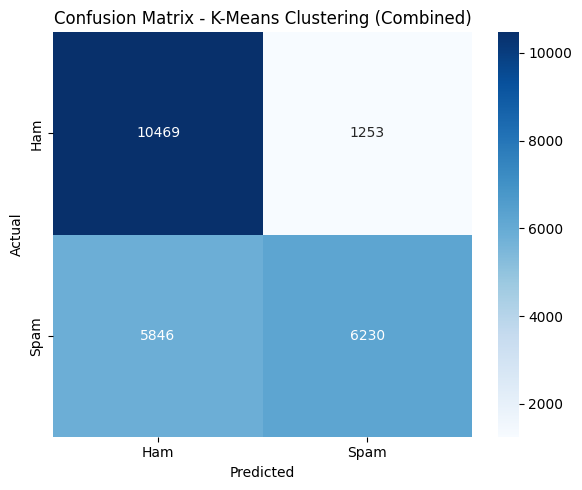

In [50]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - K-Means Clustering (Combined)")
plt.tight_layout()
plt.show()


In [ ]:
X_test_tfidf = model.preprocessor.transform(X_test)

sample_size = min(10000, X_test_tfidf.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test_tfidf.shape[0], sample_size, replace=False)

X_test_sample = X_test_tfidf[sample_idx, :]
y_test_sample = y_test.iloc[sample_idx]
y_pred_sample = y_pred[sample_idx]

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(
    X_test_sample.toarray() if hasattr(X_test_sample, 'toarray') else X_test_sample
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=y_pred_sample,
#                   cmap="viridis", alpha=0.5, s=5)

colors_pred = np.where(y_pred_sample == 0, "#1f77b4", "#2ca02c")

sc1 = ax1.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=colors_pred,
    alpha=0.7,
    s=20,
    edgecolors="white",
    linewidths=0.5
)
ax1.set_title("Predictions")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_ticks([0, 1])
cbar1.set_ticklabels(["Ham", "Spam"])

# sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=y_test_sample,
#                   cmap="viridis", alpha=0.5, s=5)
colors_true = np.where(y_test_sample == 0, "#1f77b4", "#2ca02c")

sc2 = ax2.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=colors_true,
    alpha=0.7,
    s=20,
    edgecolors="white",
    linewidths=0.5
)
ax2.set_title("True Labels")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(["Ham", "Spam"])

plt.suptitle("K-Means Clustering: PCA 2D Visualization")
plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")


In [ ]:
tfidf = model.preprocessor
feature_names = tfidf.get_feature_names_out().tolist()
cluster_centers = model.kmeans_.cluster_centers_

for cluster_id in [0, 1]:
    center = cluster_centers[cluster_id]
    top_indices = np.argsort(center)[-20:][::-1]
    mapped_label = model.map_0_ if cluster_id == 0 else model.map_1_
    print(f"\nTop 20 features for Cluster {cluster_id} (\u2192 label {mapped_label}):")
    for idx in top_indices:
        print(f"  {feature_names[idx]:30s} {center[idx]:+.4f}")



Top 20 features for Cluster 0 (→ label 0):
  url                            +0.0278
  ms                             +0.0200
  thread                         +0.0195
  microsoft                      +0.0151
  nahou                          +0.0148
  attach                         +0.0144
  use                            +0.0132
  return                         +0.0131
  class                          +0.0125
  mail                           +0.0125
  exchang                        +0.0123
  index                          +0.0123
  path                           +0.0122
  pleas                          +0.0121
  return path                    +0.0120
  microsoft exchang              +0.0120
  ms attach                      +0.0119
  exchang phonenumber            +0.0119
  thread index                   +0.0119
  binari                         +0.0119

Top 20 features for Cluster 1 (→ label 1):
  phonenumber receiv             +0.0633
  mailmanenroncom                +0.0571
  nahou   

In [ ]:
from src.features import extract_features
from src.test_emails import test_emails

df_test = extract_features(pd.Series(test_emails))
y_pred = model.predict(df_test)
y_prob = model.predict_proba(df_test)

print("=== Predictions ===")
for i, (email, pred, probs) in enumerate(zip(test_emails, y_pred, y_prob)):
    label = "SPAM" if pred == 1 else "HAM"
    print(f"[{i}] {label} (ham: {probs[0]:.2%}, spam: {probs[1]:.2%}) \u2014 {email[:70]}...")


=== Predictions ===
[0] HAM (ham: 58.55%, spam: 41.45%) — Congratulations! You won $1000 free cash prize. Click here now to clai...
[1] HAM (ham: 58.55%, spam: 41.45%) — Hi John, please find attached the meeting notes from yesterday's call....
[2] HAM (ham: 58.55%, spam: 41.45%) — URGENT: Your account has been suspended. Verify now at http://scam-sit...
[3] HAM (ham: 58.55%, spam: 41.45%) — Can we reschedule tomorrow's lunch to 1pm instead?...
[4] HAM (ham: 58.55%, spam: 41.45%) — Buy cheap v1agra 100% free shipping limited offer act now!!!...
[5] HAM (ham: 58.55%, spam: 41.45%) — For your Assignment 1, word count of 3100 is already slightly too high...
[6] HAM (ham: 58.55%, spam: 41.45%) — Please be reminded that the Assignment 1 report is due this Sunday (17...
[7] HAM (ham: 58.55%, spam: 41.45%) — Show, Last weekend, I was sick and couldn't do much of anything. So I ...
[8] HAM (ham: 58.55%, spam: 41.45%) — Supporters can now pay you in USDC, and the money lands in your accoun...
[9

In [ ]:
email_text = "Congratulations! You won $1000 free cash prize. Click here now to claim!!!"

df_single = extract_features(pd.Series([email_text]))
pred = model.predict(df_single)[0]
probs = model.predict_proba(df_single)[0]
dists = model.kmeans_.transform(model.preprocessor.transform(df_single))[0]

label = "SPAM" if pred == 1 else "HAM"
print(f"Email: {email_text}")
print(f"Prediction: {label}")
print(f"Ham probability: {probs[0]:.2%}")
print(f"Spam probability: {probs[1]:.2%}")
print(f"Distance to centroid 0: {dists[0]:.4f}")
print(f"Distance to centroid 1: {dists[1]:.4f}")


Email: Congratulations! You won $1000 free cash prize. Click here now to claim!!!
Prediction: HAM
Ham probability: 58.55%
Spam probability: 41.45%
Distance to centroid 0: 0.1582
Distance to centroid 1: 0.3454


In [ ]:
# Single dump: the model contains preprocessor, KMeans, and cluster-to-label mapping
joblib.dump(model, MODEL_OUTPUT_DIR / "kmeans_combined.pkl")
print(f"Saved K-Means model to {MODEL_OUTPUT_DIR / 'kmeans_combined.pkl'}")


Saved K-Means model to C:\Users\aungm\university\computing\cos30049-email-spam-detection\models\kmeans_combined.pkl
